In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [49]:
df = pd.read_csv('../data/adult.csv')

In [50]:
df.head(10)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
6,29,?,227026,HS-grad,9,Never-married,?,Unmarried,Black,Male,0,0,40,United-States,<=50K
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K


In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [52]:
df.shape

(48842, 15)

In [53]:
col_int = df.describe().columns

In [54]:
df.describe(include='string').T

,count,unique,top,freq
workclass,48842,9,Private,33906
education,48842,16,HS-grad,15784
marital-status,48842,7,Married-civ-spouse,22379
occupation,48842,15,Prof-specialty,6172
relationship,48842,6,Husband,19716
race,48842,5,White,41762
gender,48842,2,Male,32650
native-country,48842,42,United-States,43832
income,48842,2,<=50K,37155


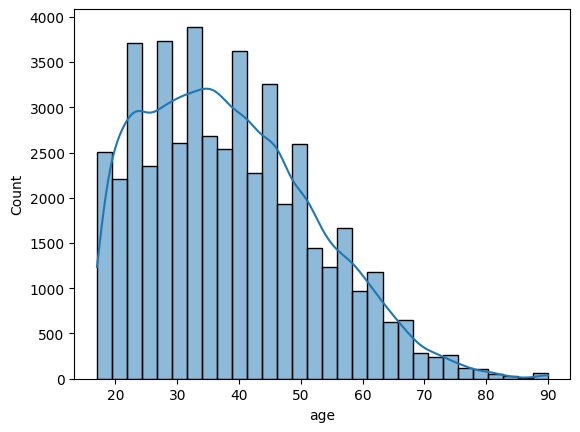

In [55]:
for col in col_int:
    sns.histplot(data=df, x=col, kde=True, bins=30)
    plt.show()

In [ ]:
df['income'].value_counts()

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [ ]:
df.shape

(48842, 15)

In [ ]:
len(df[df['capital-gain'] == 0]['capital-gain'])

44807

In [ ]:
len(df[df['capital-loss'] == 0]['capital-loss'])

46560

# Вывод по первичному анализу датасета Adult
В ходе анализа датасета Adult (Census Income) была изучена структура данных, распределения признаков и целевая переменная.

## Общая характеристика данных
Датасет содержит 48 842 наблюдения. Признаки включают как числовые, так и категориальные переменные. Данные разнородны по типам и требуют предварительной обработки перед обучением моделей.

## Целевая переменная
Целевая переменная `income` имеет два класса: `<=50K` и `>50K`. Наблюдается дисбаланс классов, что необходимо учитывать при выборе метрик качества (предпочтительнее F1-score).

## Числовые признаки
Распределения числовых признаков не являются нормальными. У ряда переменных наблюдается сильная асимметрия и наличие выбросов.
Наиболее выраженные отклонения наблюдаются у признаков `capital-gain` и `capital-loss`.

## Признаки capital-gain и capital-loss
В данных признаках присутствует большое количество нулевых значений. Это не пропуски, а отражение отсутствия операций с капиталом у большинства наблюдений. Признаки являются разреженными.

## Вывод
Датасет представляет собой задачу бинарной классификации со смешанными типами признаков, дисбалансом классов и неравномерными распределениями.
Перед обучением моделей требуется кодирование категориальных признаков и дальнейшая подготовка данных. Датасет готов к этапу построения моделей машинного обучения.

In [ ]:
df = df.drop('education', axis=1)

In [ ]:
df.head()

,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
(df['workclass'] == '?').sum()

np.int64(2799)

In [ ]:
(df['marital-status'] == '?').sum()

np.int64(0)

In [ ]:
(df['occupation'] == '?').sum()

np.int64(2809)

In [ ]:
(df['relationship'] == '?').sum()

np.int64(0)

In [ ]:
df['race'].unique()

<StringArray>
['Black', 'White', 'Asian-Pac-Islander', 'Other', 'Amer-Indian-Eskimo']
Length: 5, dtype: str

In [ ]:
df['gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [ ]:
df['native-country'].unique()

<StringArray>
[             'United-States',                          '?',
                       'Peru',                  'Guatemala',
                     'Mexico',         'Dominican-Republic',
                    'Ireland',                    'Germany',
                'Philippines',                   'Thailand',
                      'Haiti',                'El-Salvador',
                'Puerto-Rico',                    'Vietnam',
                      'South',                   'Columbia',
                      'Japan',                      'India',
                   'Cambodia',                     'Poland',
                       'Laos',                    'England',
                       'Cuba',                     'Taiwan',
                      'Italy',                     'Canada',
                   'Portugal',                      'China',
                  'Nicaragua',                   'Honduras',
                       'Iran',                   'Scotland',
          

In [ ]:
(df['native-country'] == '?').sum()

np.int64(857)

In [ ]:
df['income'].unique()

<StringArray>
['<=50K', '>50K']
Length: 2, dtype: str

In [ ]:
cols = [
    'workclass',
    'occupation',
    'native-country'
]

In [ ]:
df['workclass'].mode()

0    Private
Name: workclass, dtype: str

In [ ]:
for col in cols:
    df[col] = df[col].replace('?', df[col].mode()[0])

In [ ]:
num_cols = [
    'age',
    'fnlwgt',
    'educational-num',
    'capital-gain',
    'capital-loss',
    'hours-per-week'
]

cat_cols = [
    'workclass',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'gender',
    'native-country'
]

`LogisticRegression`

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [ ]:
X = df.drop(columns=['income'])
y = df['income']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
param_grid = {
    'logisticregression__C': [0.01, 0.1, 10],
    'logisticregression__class_weight': [None, 'balanced']
}

In [ ]:
pipeline = make_pipeline(
    preprocessor,
    LogisticRegression(max_iter=1000)
)

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'logisticregression__C': [0.01, 0.1, ...], 'logisticregression__class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",Tr

In [ ]:
y_pred = grid.predict(X_test)

In [ ]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print("accuracy_score:", accuracy_score(y_test, y_pred))
print("f1_score:", f1_score(y_test, y_pred, average='macro'))

accuracy_score: 0.8526973078104207
f1_score: 0.7826434055255609


## `DecisionTree`

In [ ]:
df.head()

,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,Private,103497,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
X = df.drop(columns=['income'])
y = df['income']

In [ ]:
num_cols = [
    'age', 'fnlwgt', 'educational-num',
    'capital-gain', 'capital-loss', 'hours-per-week'
]

cat_cols = [
    'workclass', 'marital-status', 'occupation',
    'relationship', 'race', 'gender', 'native-country'
]

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
model = make_pipeline(
    preprocessor,
    DecisionTreeClassifier(random_state=42)
)

In [ ]:
params_grid = {
    'decisiontreeclassifier__max_depth': [3, 5, 10, None],
    'decisiontreeclassifier__min_samples_split': [2, 5, 10],
    'decisiontreeclassifier__min_samples_leaf': [1, 2, 5]
}

In [ ]:
grid = GridSearchCV(
    model,
    params_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'decisiontreeclassifier__max_depth': [3, 5, ...], 'decisiontreeclassifier__min_samples_leaf': [1, 2, ...], 'decisiontreeclassifier__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-valida

In [ ]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print("accuracy_score:", accuracy_score(y_test, y_pred))
print("f1_score:", f1_score(y_test, y_pred, average='macro'))

accuracy_score: 0.8206571808782884
f1_score: 0.7411981638398089


## `RandomForest`

In [ ]:
pipe = make_pipeline(
    preprocessor,
    RandomForestClassifier(random_state=42)
)

In [ ]:
params_grid = {
    'randomforestclassifier__n_estimators': [100, 200],
    'randomforestclassifier__max_depth': [5, 10, None],
    'randomforestclassifier__min_samples_split': [2, 5],
    'randomforestclassifier__class_weight': [None, 'balanced']
}

In [ ]:
grid = GridSearchCV(
    pipe,
    params_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

grid.fit(X_train, y_train)

KeyboardInterrupt: 

In [ ]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print("accuracy_score:", accuracy_score(y_test, y_pred))
print("f1_score:", f1_score(y_test, y_pred, average='macro'))

accuracy_score: 0.8290510799467704
f1_score: 0.7551470033801664


## `XGBoost`

In [ ]:
pipe = make_pipeline(
    preprocessor,
    XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    )
)

In [ ]:
params_grid = {
    'xgbclassifier__n_estimators': [100, 200],
    'xgbclassifier__max_depth': [3, 5, 7],
    'xgbclassifier__learning_rate': [0.01, 0.1, 0.2],
    'xgbclassifier__subsample': [0.8, 1.0]
}

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_train)

grid = GridSearchCV(
    pipe,
    params_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

grid.fit(X_train, y_encoded)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'xgbclassifier__learning_rate': [0.01, 0.1, ...], 'xgbclassifier__max_depth': [3, 5, ...], 'xgbclassifier__n_estimators': [100, 200], 'xgbclassifier__subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and c

In [ ]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_test = le.fit_transform(y_test)
print("accuracy_score:", accuracy_score(y_test, y_pred))
print("f1_score:", f1_score(y_test, y_pred, average='macro'))

accuracy_score: 0.8196335346504248
f1_score: 0.7385193550308011


## Вывод по проделанной работе

В ходе работы был выполнен анализ датасета Adult, включающего смешанные числовые и категориальные признаки для решения задачи бинарной классификации уровня дохода. На первом этапе были изучены структура данных, распределения признаков и целевая переменная `income`. Было установлено, что в датасете присутствует дисбаланс классов, поэтому для оценки качества моделей, помимо accuracy, использовалась метрика `F1-score`.

В процессе предварительной обработки были удалены дублирующие признаки, заменены значения `?` в категориальных столбцах на наиболее частотные значения, а также выделены числовые и категориальные признаки для дальнейшего преобразования. Для числовых признаков использовалось масштабирование `StandardScaler`, а для категориальных — кодирование `OneHotEncoder`. Это позволило подготовить данные к обучению моделей машинного обучения.

Для сравнения были обучены несколько алгоритмов классификации: `LogisticRegression`, `DecisionTreeClassifier`, `RandomForestClassifier` и `XGBClassifier`. В качестве схемы валидации применялись `StratifiedKFold` и `GridSearchCV`, что позволило подобрать гиперпараметры и получить более устойчивую оценку качества моделей.

По итогам экспериментов наилучший результат показала модель `LogisticRegression`, достигнув accuracy `0.8527` и `F1-score` `0.7826`. Модели на основе деревьев решений также показали хорошие результаты, но уступили логистической регрессии по итоговым метрикам. Это говорит о том, что для данного набора данных линейная модель после корректной предобработки признаков оказалась наиболее эффективной.

Таким образом, в работе был выполнен полный цикл решения задачи машинного обучения: от первичного анализа данных и их очистки до обучения, настройки и сравнения нескольких моделей классификации. Полученные результаты подтверждают, что датасет Adult можно успешно использовать для построения предсказательной модели дохода при условии корректной обработки признаков.